<a href="https://colab.research.google.com/github/HariKiran30/Urban-Area-Analysis-using-Python-and-GIS/blob/main/Py_GIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# @title
!pip install osmnx geopandas folium matplotlib shapely -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 9.5 MB/s eta 0:00:00


In [4]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from shapely.geometry import Point

In [5]:
# 1km span in (west, south, east, north) format
# Center was roughly 17.385, 78.486
bbox = (78.481, 17.380, 78.491, 17.390)

print("Downloading road network...")
# Ensure you use the simplified bbox call for OSMnx 2.x
G = ox.graph_from_bbox(bbox=bbox, network_type='drive')

print("Downloading buildings...")
tags = {'building': True}
buildings = ox.features_from_bbox(bbox=bbox, tags=tags)

# Filter for polygons
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]

print(f"Success! Loaded {len(buildings)} buildings.")

Success! Loaded 1645 buildings.


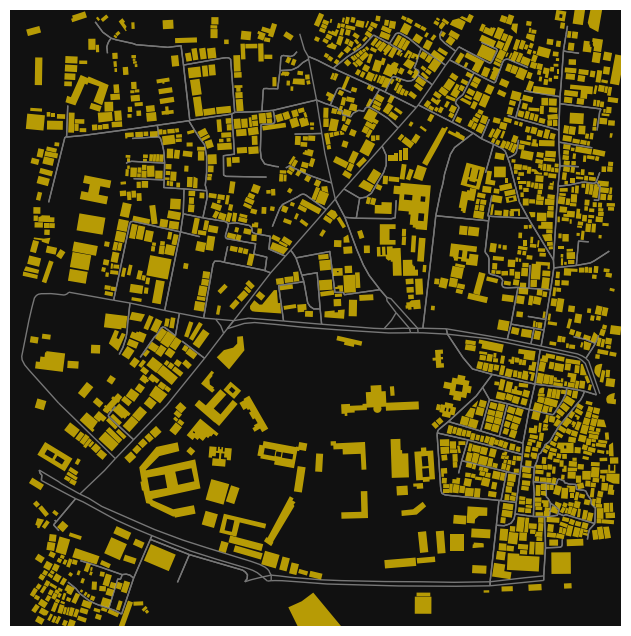

In [6]:
# Plot the network and buildings together
fig, ax = ox.plot_graph(G, show=False, close=False, edge_color='#777', node_size=0)
buildings.plot(ax=ax, color='gold', alpha=0.7)
plt.show()

In [7]:
#Step 3: Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

print("Roads:", len(edges))
print("Nodes:", len(nodes))

Roads: 530
Nodes: 241


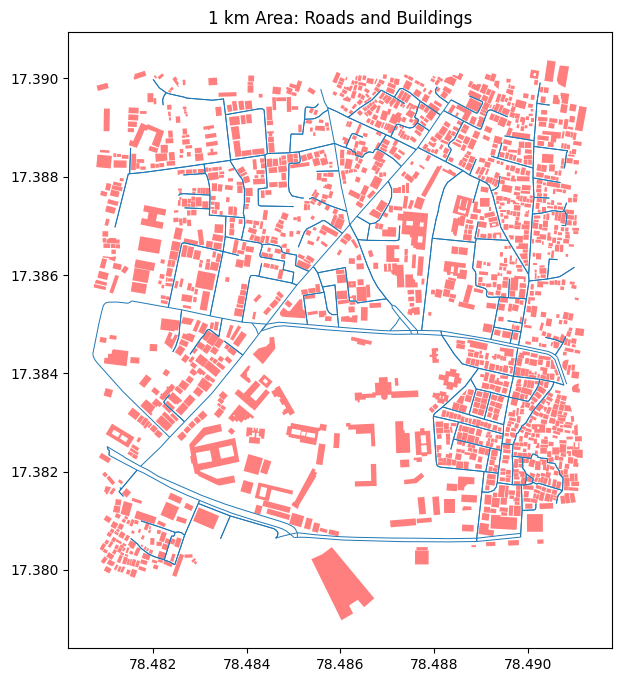

In [8]:
# Step 4: Basic Visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

edges.plot(ax=ax, linewidth=0.7)
buildings.plot(ax=ax, color='red', alpha=0.5)

plt.title("1 km Area: Roads and Buildings")
plt.show()

In [9]:
# Step 5: Area Calculation (IMPORTANT)
import geopandas as gpd

# Convert CRS for accurate area (meters)
buildings_proj = buildings.to_crs(epsg=3857)

buildings_proj['area'] = buildings_proj.area

print("Total building area (sq.m):", buildings_proj['area'].sum())

Total building area (sq.m): 352223.0175795896


In [10]:
# Step 6: Building Density (VERY IMPORTANT)
# Total area of bbox (~1 km² approx)
area_km2 = 1  # since you defined ~1 km region

building_density = len(buildings) / area_km2

print("Building density (per sq.km):", building_density)

Building density (per sq.km): 1645.0


In [11]:
# Step 7: Road Length Analysis
total_road_length = edges['length'].sum()

print("Total road length (km):", total_road_length / 1000)

Total road length (km): 33.16948999099778


In [12]:
#Step 8: Buffer Analysis (KEY GIS CONCEPT)

# Example: buildings within 300 meters of center
from shapely.geometry import Point

# Center point
center = Point(78.486, 17.385)

center_gdf = gpd.GeoDataFrame(geometry=[center], crs="EPSG:4326")

# Convert to meters
center_proj = center_gdf.to_crs(epsg=3857)
buildings_proj = buildings.to_crs(epsg=3857)

# Create 300m buffer
buffer = center_proj.buffer(300)

# Find buildings inside buffer
nearby = buildings_proj[buildings_proj.intersects(buffer[0])]

print("Buildings within 300m:", len(nearby))

Buildings within 300m: 174


In [14]:
# Interactive Map using Folium
m = folium.Map(location=[17.385, 78.486], zoom_start=15,
               tiles='CartoDB positron')

# Add buildings
for _, row in buildings.iterrows():
    folium.GeoJson(row.geometry).add_to(m)

m.save("hyderabad_map.html")
m